# Aprendizaje no supervisado: PCA y clustering

**Módulo 4 — Ciencia de Datos**

En el notebook anterior trabajamos con **clasificación supervisada**, donde el modelo aprende a predecir una etiqueta conocida. Ahora damos un giro completo:

- Los datos **no tienen etiquetas**.
- El objetivo cambia: ya no es predecir, sino **descubrir estructura** en los datos.

Vamos a recorrer dos técnicas del aprendizaje no supervisado:

1. **Reducción de dimensionalidad** con PCA: cómo simplificar el espacio de variables.
2. **Clustering** con k-means: cómo agrupar observaciones similares.

Y vamos a ver algo importante: como no hay etiquetas correctas contra las cuales comparar, **necesitamos métricas específicas** que evalúen propiedades de los resultados.

Para mantener continuidad con los notebooks anteriores, usamos el dataset **Iris**, que ya conocemos. Este caso tiene una ventaja didáctica única: aunque vamos a hacer aprendizaje no supervisado (sin usar las etiquetas), sí las conocemos, así que vamos a poder comparar qué descubre el algoritmo con la "verdad" real.


## 1. Importación de librerías


In [1]:
# Manejo de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Datos y herramientas de scikit-learn
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Métricas no supervisadas
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Configuración estética
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

SEMILLA = 42

## 2. Carga del dataset

Iris: tres especies de flores, cuatro variables, 150 observaciones.


In [2]:
# Cargamos Iris
datos = load_iris()
X = pd.DataFrame(datos.data, columns=datos.feature_names)
y = pd.Series(datos.target, name="especie")  # Las guardamos, pero NO las usamos
nombres_clases = datos.target_names

print(f"Observaciones: {X.shape[0]}")
print(f"Variables: {X.shape[1]}")
print(f"Especies (no las vamos a usar en el clustering): {list(nombres_clases)}")
X.head()

Observaciones: 150
Variables: 4
Especies (no las vamos a usar en el clustering): [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


> **Nota teórica:** los algoritmos que dependen de **distancias** (k-means) o de **varianzas** (PCA) son sensibles a la escala de las variables. La normalización es prácticamente obligatoria.


In [3]:
# Escalado de variables
escalador = StandardScaler()
X_esc = escalador.fit_transform(X)
print("Datos escalados a media 0 y desvío 1.")

Datos escalados a media 0 y desvío 1.


# Parte 1: Reducción de dimensionalidad con PCA

## 3. Aplicando PCA

Iris tiene 4 variables, lo que dificulta su visualización (no podemos graficar más allá de 3 dimensiones). Vamos a aplicar **PCA** para proyectar los datos a 2 dimensiones manteniendo la mayor cantidad posible de información (varianza).

Recordemos: las **componentes principales** son combinaciones lineales de las variables originales, ordenadas de mayor a menor varianza explicada.


In [4]:
# Aplicamos PCA con 2 componentes
pca = PCA(n_components=2, random_state=SEMILLA)
X_pca = pca.fit_transform(X_esc)

print(f"Forma original: {X_esc.shape}")
print(f"Forma después de PCA: {X_pca.shape}")
print()
print("Varianza explicada por cada componente:")
for i, var in enumerate(pca.explained_variance_ratio_, start=1):
    print(f"  Componente {i}: {var:.4f} ({var*100:.2f}%)")
print(f"\nVarianza explicada acumulada: {sum(pca.explained_variance_ratio_)*100:.2f}%")

Forma original: (150, 4)
Forma después de PCA: (150, 2)

Varianza explicada por cada componente:
  Componente 1: 0.7296 (72.96%)
  Componente 2: 0.2285 (22.85%)

Varianza explicada acumulada: 95.81%


Con solo 2 componentes recuperamos cerca del 95% de la información. Las 4 variables originales eran en gran parte **redundantes**.

Visualicemos los datos proyectados. Como esto es un material didáctico y queremos ilustrar lo que está pasando, los coloreamos según la especie real (que en un problema realmente no supervisado, no tendríamos).


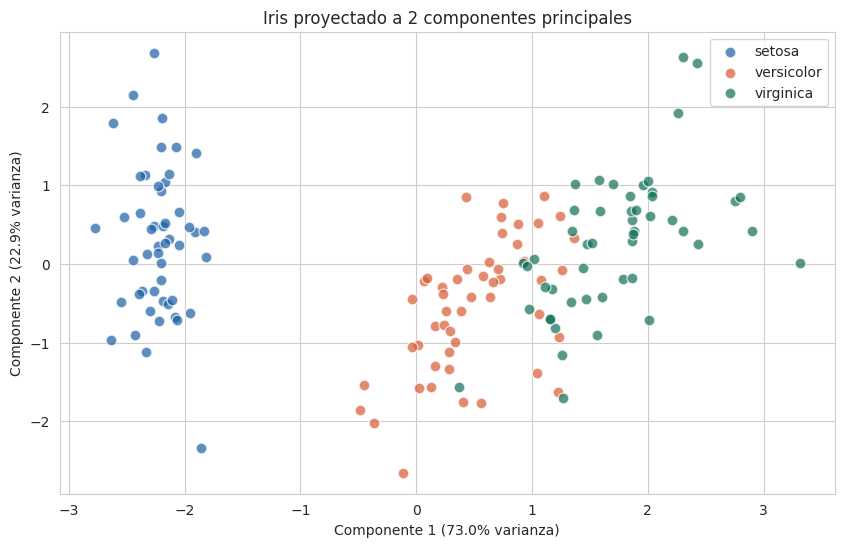

In [5]:
# Visualización de los datos proyectados a 2D
plt.figure(figsize=(10, 6))
colores = ["#185FA5", "#D85A30", "#0F6E56"]

for i, nombre in enumerate(nombres_clases):
    plt.scatter(
        X_pca[y == i, 0], X_pca[y == i, 1],
        c=colores[i], label=nombre, s=60, alpha=0.7, edgecolor="white"
    )

plt.xlabel(f"Componente 1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)")
plt.ylabel(f"Componente 2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)")
plt.title("Iris proyectado a 2 componentes principales")
plt.legend()
plt.show()

**Observaciones:**

- Aunque redujimos de 4 a 2 dimensiones, las especies siguen siendo distinguibles.
- *Setosa* aparece claramente separada.
- *Versicolor* y *Virginica* se superponen parcialmente.

> **Importante:** las componentes 1 y 2 **no son** variables originales. Son **combinaciones lineales** de las cuatro variables. Veamos los pesos:


In [6]:
# ¿De qué están compuestas las componentes?
componentes = pd.DataFrame(
    pca.components_.T,
    columns=["Componente 1", "Componente 2"],
    index=X.columns
)
print("Pesos de cada variable original en cada componente:")
componentes.round(3)

Pesos de cada variable original en cada componente:


,Componente 1,Componente 2
sepal length (cm),0.521,0.377
sepal width (cm),-0.269,0.923
petal length (cm),0.580,0.024
petal width (cm),0.565,0.067


## 4. ¿Cuántas componentes conservar? Métricas de PCA

Elegimos 2 componentes intuitivamente para poder visualizar. Pero en problemas reales necesitamos un criterio. Las principales herramientas son:

- **Varianza explicada por componente**: cuánta información captura cada una.
- **Varianza acumulada**: cuánta información conservamos al sumar las primeras k componentes.
- **Gráfico de sedimentación (scree plot)**: ayuda a identificar el "codo" donde agregar componentes deja de aportar.

Aplicamos PCA con **todas las componentes posibles** para ver el panorama completo.


In [7]:
# PCA con todas las componentes
pca_completo = PCA(n_components=4, random_state=SEMILLA)
pca_completo.fit(X_esc)

# Tabla resumen
varianza = pca_completo.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza)

tabla_var = pd.DataFrame({
    "Componente": [f"PC{i+1}" for i in range(len(varianza))],
    "Varianza explicada": varianza.round(4),
    "Varianza acumulada": varianza_acumulada.round(4),
    "% acumulado": (varianza_acumulada * 100).round(2)
})
print("Varianza explicada por componente:")
tabla_var

Varianza explicada por componente:


,Componente,Varianza explicada,Varianza acumulada,% acumulado
0,PC1,0.7296,0.7296,72.96
1,PC2,0.2285,0.9581,95.81
2,PC3,0.0367,0.9948,99.48
3,PC4,0.0052,1.0000,100.00


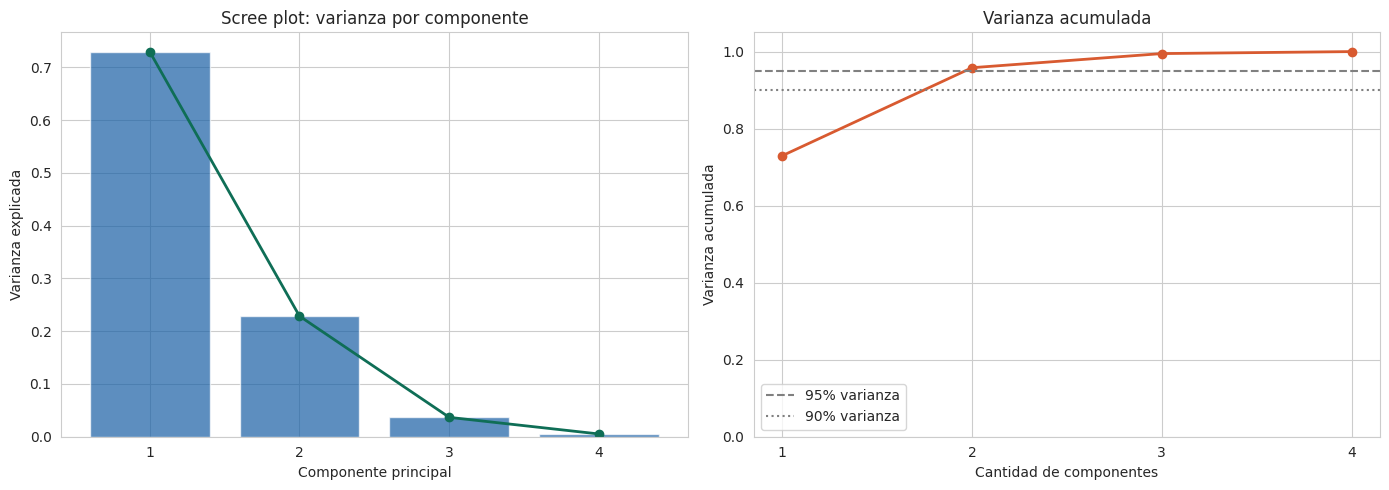

In [8]:
# Scree plot + curva de varianza acumulada
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
componentes_x = range(1, len(varianza) + 1)

# Scree plot
axes[0].bar(componentes_x, varianza, color="#185FA5", alpha=0.7, edgecolor="white")
axes[0].plot(componentes_x, varianza, marker="o", color="#0F6E56", linewidth=2)
axes[0].set_xticks(componentes_x)
axes[0].set_xlabel("Componente principal")
axes[0].set_ylabel("Varianza explicada")
axes[0].set_title("Scree plot: varianza por componente")

# Varianza acumulada
axes[1].plot(componentes_x, varianza_acumulada, marker="o", linewidth=2, color="#D85A30")
axes[1].axhline(y=0.95, color="gray", linestyle="--", label="95% varianza")
axes[1].axhline(y=0.90, color="gray", linestyle=":", label="90% varianza")
axes[1].set_xticks(componentes_x)
axes[1].set_xlabel("Cantidad de componentes")
axes[1].set_ylabel("Varianza acumulada")
axes[1].set_title("Varianza acumulada")
axes[1].set_ylim(0, 1.05)
axes[1].legend()

plt.tight_layout()
plt.show()

**Cómo leer estos gráficos:**

- **Scree plot (izquierda)**: cada barra muestra la varianza que aporta una componente. La primera concentra la mayor parte, y a partir de la tercera ya casi no aportan información.
- **Varianza acumulada (derecha)**: muestra cuánta información total conservamos al ir sumando componentes. Con 2 componentes superamos el 95%.

**Criterios prácticos para elegir el número de componentes:**

1. **Umbral de varianza acumulada**: conservar las componentes necesarias para alcanzar un porcentaje fijado de antemano (típicamente 80%, 90% o 95%).
2. **Codo del scree plot**: buscar el punto donde la varianza aportada cae bruscamente.
3. **Objetivo concreto**: si solo queremos visualizar, 2 o 3 componentes. Si vamos a usar las componentes como insumo de otro algoritmo, podemos conservar más.

Para este caso, **2 componentes** es razonable: explican el 95% de la varianza y permiten visualización directa.


# Parte 2: Clustering con k-means

## 5. Agrupando sin usar las etiquetas

Ahora hacemos algo conceptualmente muy distinto: **olvidamos las etiquetas** y dejamos que el algoritmo descubra grupos por sí solo.

Recordemos la mecánica de k-means:
1. Se elige un número k de grupos.
2. Se inicializan k centroides al azar.
3. Cada observación se asigna al centroide más cercano.
4. Se recalculan los centroides como el promedio de sus observaciones.
5. Se repiten los pasos 3 y 4 hasta que las asignaciones se estabilicen.

Como sabemos que hay 3 especies, vamos a empezar con k=3 para poder comparar el resultado con la realidad.


In [9]:
# Aplicamos k-means con k=3 (sin usar y)
kmeans = KMeans(n_clusters=3, random_state=SEMILLA, n_init=10)
clusters = kmeans.fit_predict(X_esc)

print("Cantidad de observaciones en cada cluster:")
for i in range(3):
    print(f"  Cluster {i}: {sum(clusters == i)} casos")

Cantidad de observaciones en cada cluster:
  Cluster 0: 53 casos
  Cluster 1: 50 casos
  Cluster 2: 47 casos


## 6. Comparando lo que descubrió k-means con la realidad

Visualicemos los grupos sobre las componentes principales. A la izquierda mostramos lo que **descubrió k-means** (sin saber las especies); a la derecha, las **especies reales** (para comparar).


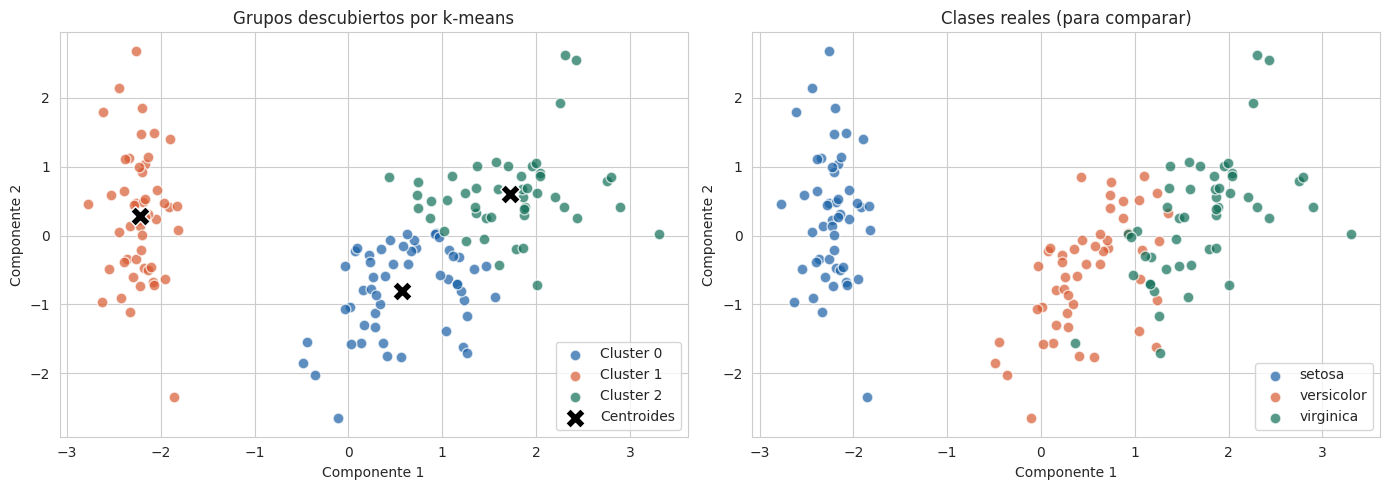

In [10]:
# Visualización: clusters vs clases reales
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: lo que descubrió k-means
for i in range(3):
    axes[0].scatter(
        X_pca[clusters == i, 0], X_pca[clusters == i, 1],
        c=colores[i], label=f"Cluster {i}", s=60, alpha=0.7, edgecolor="white"
    )
centroides_pca = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(
    centroides_pca[:, 0], centroides_pca[:, 1],
    c="black", marker="X", s=200, label="Centroides", edgecolor="white"
)
axes[0].set_title("Grupos descubiertos por k-means")
axes[0].set_xlabel("Componente 1")
axes[0].set_ylabel("Componente 2")
axes[0].legend()

# Gráfico 2: las clases reales
for i, nombre in enumerate(nombres_clases):
    axes[1].scatter(
        X_pca[y == i, 0], X_pca[y == i, 1],
        c=colores[i], label=nombre, s=60, alpha=0.7, edgecolor="white"
    )
axes[1].set_title("Clases reales (para comparar)")
axes[1].set_xlabel("Componente 1")
axes[1].set_ylabel("Componente 2")
axes[1].legend()

plt.tight_layout()
plt.show()

**Lo que se observa:**

- Los grupos descubiertos por k-means se parecen bastante a las especies reales, pero **no son idénticos**.
- *Setosa* (la especie más separada) la captura completa.
- *Versicolor* y *Virginica* se mezclan parcialmente.
- Los **colores no coinciden** entre los dos gráficos: k-means etiqueta los grupos como 0, 1, 2 sin saber a qué especie corresponden. La numeración es arbitraria.

> **Punto clave:** k-means encontró estructura, pero **no sabe** que esa estructura corresponde a especies.

En un problema realmente no supervisado, no tendríamos las etiquetas y por lo tanto **no podríamos hacer esta comparación**. Eso plantea una pregunta importante: ¿cómo sabemos si el clustering es "bueno"?


## 7. ¿Cómo evaluar la calidad del clustering?

Acá tenemos un desafío particular: **no hay etiquetas correctas contra las cuales comparar** (en un problema real). Necesitamos métricas que evalúen **propiedades geométricas** de los grupos.

Las tres principales son:

- **Inercia**: suma de las distancias cuadradas de cada punto a su centroide. Mide qué tan **compactos** son los grupos. Cuanto menor, más compactos. Es la base del **método del codo**.

- **Coeficiente de silueta (silhouette score)**: combina **cohesión** (cuán cerca están los puntos dentro de su cluster) y **separación** (cuán lejos están de los otros clusters). Va de -1 a 1; valores cercanos a 1 indican grupos bien definidos.

- **Índice de Davies-Bouldin**: mide la relación entre la dispersión dentro de cada cluster y la separación entre clusters. **Cuanto menor, mejor.**

Veamos los valores para nuestro clustering con k=3:


In [11]:
# Métricas para el clustering con k=3
inercia = kmeans.inertia_
silueta = silhouette_score(X_esc, clusters)
db_score = davies_bouldin_score(X_esc, clusters)

print(f"Métricas para k-means con k=3:")
print(f"  Inercia: {inercia:.4f}")
print(f"  Coeficiente de silueta: {silueta:.4f}  (cerca de 1 es mejor)")
print(f"  Índice de Davies-Bouldin: {db_score:.4f}  (cerca de 0 es mejor)")

Métricas para k-means con k=3:
  Inercia: 139.8205
  Coeficiente de silueta: 0.4599  (cerca de 1 es mejor)
  Índice de Davies-Bouldin: 0.8336  (cerca de 0 es mejor)


Estos valores por sí solos no nos dicen mucho. Lo realmente útil es **compararlos para distintos valores de k**.

## 8. Eligiendo k combinando varias métricas

Probemos distintos valores de k y calculemos las tres métricas. Es importante **no usar una sola métrica como criterio único**, sino combinarlas junto con conocimiento del problema.


In [12]:
# Probamos distintos valores de k
valores_k = range(2, 11)  # silueta y Davies-Bouldin requieren k >= 2
inercias = []
siluetas = []
db_scores = []

for k in valores_k:
    km = KMeans(n_clusters=k, random_state=SEMILLA, n_init=10)
    labels = km.fit_predict(X_esc)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(X_esc, labels))
    db_scores.append(davies_bouldin_score(X_esc, labels))

# Tabla resumen
resultados_k = pd.DataFrame({
    "k": list(valores_k),
    "Inercia": [round(v, 2) for v in inercias],
    "Silueta": [round(v, 4) for v in siluetas],
    "Davies-Bouldin": [round(v, 4) for v in db_scores]
})
print("Métricas para distintos valores de k:")
resultados_k

Métricas para distintos valores de k:


,k,Inercia,Silueta,Davies-Bouldin
0,2,222.36,0.5818,0.5933
1,3,139.82,0.4599,0.8336
2,4,114.09,0.3869,0.8698
3,5,90.93,0.3459,0.9483
4,6,81.54,0.3171,1.0537
5,7,72.63,0.3202,0.9905
6,8,62.54,0.3387,0.9150
7,9,55.12,0.3424,0.9032
8,10,47.39,0.3518,0.8748


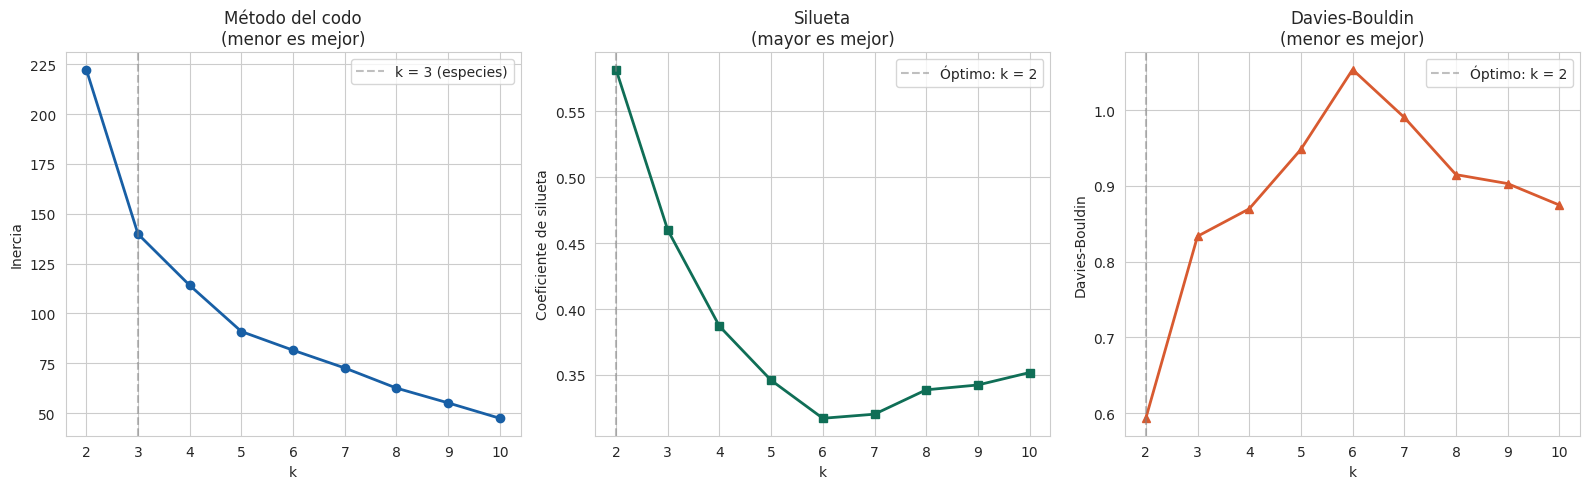


Mejor k según silueta: 2
Mejor k según Davies-Bouldin: 2


In [13]:
# Visualización conjunta
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Inercia
axes[0].plot(valores_k, inercias, marker="o", linewidth=2, color="#185FA5")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inercia")
axes[0].set_title("Método del codo\n(menor es mejor)")
axes[0].axvline(x=3, color="gray", linestyle="--", alpha=0.5, label="k = 3 (especies)")
axes[0].legend()

# Silueta
axes[1].plot(valores_k, siluetas, marker="s", linewidth=2, color="#0F6E56")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Coeficiente de silueta")
axes[1].set_title("Silueta\n(mayor es mejor)")
mejor_k_sil = list(valores_k)[np.argmax(siluetas)]
axes[1].axvline(x=mejor_k_sil, color="gray", linestyle="--", alpha=0.5, label=f"Óptimo: k = {mejor_k_sil}")
axes[1].legend()

# Davies-Bouldin
axes[2].plot(valores_k, db_scores, marker="^", linewidth=2, color="#D85A30")
axes[2].set_xlabel("k")
axes[2].set_ylabel("Davies-Bouldin")
axes[2].set_title("Davies-Bouldin\n(menor es mejor)")
mejor_k_db = list(valores_k)[np.argmin(db_scores)]
axes[2].axvline(x=mejor_k_db, color="gray", linestyle="--", alpha=0.5, label=f"Óptimo: k = {mejor_k_db}")
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"\nMejor k según silueta: {mejor_k_sil}")
print(f"Mejor k según Davies-Bouldin: {mejor_k_db}")

**Lectura conjunta de los gráficos:**

- El **método del codo** muestra un quiebre entre k=2 y k=3.
- La **silueta** sugiere k=2 como óptimo.
- **Davies-Bouldin** suele coincidir o estar muy cerca.

**Pero sabemos que hay 3 especies. ¿Por qué las métricas dicen otra cosa?**

Las métricas señalan k=2 porque, geométricamente, *Setosa* está tan separada del resto que dos grupos forman una división muy "limpia": un grupo es *Setosa* y otro es *Versicolor + Virginica*. Eso es óptimo desde la geometría, pero pierde información biológica importante (no distingue dos especies que sí son distintas).

> **Punto clave que mencionamos en la teoría:** las métricas de clustering evalúan **propiedades geométricas**, no si los grupos tienen significado en el mundo real. Una métrica geométricamente óptima puede no ser la respuesta correcta para el problema.

**Conclusión:** las métricas son herramientas para guiar la decisión, no para tomarla por nosotros. El **conocimiento del dominio** es indispensable en clustering.


## 9. k-NN vs k-means: misma idea, propósitos distintos

Para cerrar, vale la pena recuperar una conexión que mencionamos en la teoría. Ambos algoritmos comparten la **noción de distancia entre observaciones**, pero la usan de maneras muy distintas:

|  | k-NN | k-means |
|---|---|---|
| Tipo de aprendizaje | Supervisado | No supervisado |
| Necesita etiquetas | Sí | No |
| Qué hace | Predice la clase de una observación nueva | Agrupa observaciones similares |
| Qué hace con las distancias | Encuentra a los k vecinos más cercanos | Asigna al centroide más cercano |
| Hay un modelo entrenado | No (lazy learner) | Sí (los centroides) |
| Métricas para evaluar | Accuracy, precision, recall, F1, etc. | Inercia, silueta, Davies-Bouldin |

La similitud en el nombre no es casual: ambos están construidos sobre la misma intuición geométrica. Pero como vimos a lo largo de los dos notebooks, esa intuición se traduce en problemas, algoritmos y métricas completamente distintos.


## 10. Síntesis del notebook

Recorrimos las dos grandes familias del aprendizaje no supervisado, conectándolas con el material teórico:

| Sección | Concepto de la teoría |
|---|---|
| PCA sobre Iris | Reducción de dimensionalidad |
| Pesos de las componentes | Las PC son combinaciones de las variables originales |
| Scree plot y varianza acumulada | **Métricas para elegir cantidad de componentes** |
| K-means con k=3 | Clustering basado en distancias |
| Comparación con clases reales | El clustering descubre estructura pero no la interpreta |
| Inercia, silueta y Davies-Bouldin | **Métricas para evaluar calidad del clustering** |
| Discrepancia entre métricas y dominio | Las métricas son geométricas, no semánticas |
| Comparación k-NN / k-means | Conexión entre supervisado y no supervisado |

**Lo más importante que aprendimos sobre métricas no supervisadas:**

Las métricas de PCA y clustering evalúan propiedades **geométricas** de los resultados (varianza capturada, compacidad y separación de grupos), no si tienen significado en el mundo real. Por eso, en aprendizaje no supervisado el **conocimiento del dominio** es indispensable.

En Iris lo vimos en acción: la silueta sugería k=2 (porque *Setosa* está muy separada), pero biológicamente sabemos que hay 3 especies. Una métrica geométricamente óptima puede ocultar información valiosa.

Con esto cerramos el módulo. En próximas materias van a profundizar en cada uno de estos temas, pero con esta base están en condiciones de entender de qué se trata el aprendizaje automático y cómo se evalúa de manera responsable.
